In [ ]:
import copy
import json
import shutil
import time
from pathlib import Path

In [ ]:
from PIL import Image, ImageOps

## Import torch framwork

In [ ]:
import torch
import torch.nn as nn

In [ ]:
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchvision.models import EfficientNet_V2_S_Weights, efficientnet_v2_s


## Mount Google Drive in Colab Content

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Check Hardware

In [ ]:
if torch.cuda.is_available():
    print("CUDA is available! GPU details:")
    print(f"  Current device: {torch.cuda.current_device()}")
    print(f"  Device name: {torch.cuda.get_device_name(0)}")
else:
    print("CUDA is not available. Running on CPU.")

CUDA is available! GPU details:
  Current device: 0
  Device name: NVIDIA A100-SXM4-40GB


## Decleare Relative Paths to OpenBrush 22 K Dataset in Drvie



In [ ]:
LOCAL_DATASET_DIR = Path("/content/Aegis-Art-Atelier-22K")
TRAIN_MANIFEST = LOCAL_DATASET_DIR / "train_manifest.jsonl"
VAL_MANIFEST = LOCAL_DATASET_DIR / "val_manifest.jsonl"
TEST_MANIFEST = LOCAL_DATASET_DIR / "test_manifest.jsonl"


In [ ]:
LOCAL_OUTPUT_DIR = Path("/content/art_style_identifier_checkpoints")
DRIVE_OUTPUT_DIR = Path("/content/drive/MyDrive/aegis_art_atelier/art_style_identifier")


## Set the  Chosen Art Styles to  CNN

In [ ]:
CNN_CLASSES = [
    "Impressionism", "Realism", "Romanticism", "Post-Impressionism",
    "Expressionism", "Baroque", "Mannerism", "Northern-Renaissance",
    "Abstract", "Rococo", "Cubism", "Pop Art", "Naive", "Ukiyo-e", "Fauvism",
]

In [ ]:
NUM_CLASSES = len(CNN_CLASSES)

Maps the manifest's raw effective_style value to a final CNN class.
Pointillism is intentionally merged into Post-Impressionism (a deliberate
choice, accepting a larger, slightly mixed class in exchange for not
discarding the Pointillism images entirely). Any raw style NOT listed here
is excluded from this classifier's dataset (still used for the VLM, just
not here).

In [ ]:
RAW_TO_CNN_CLASS = {
    "Impressionism": "Impressionism",
    "Realism": "Realism",
    "Romanticism": "Romanticism",
    "Post": "Post-Impressionism",
    "Pointillism": "Post-Impressionism",
    "Expressionism": "Expressionism",
    "Baroque": "Baroque",
    "Mannerism": "Mannerism",
    "Northern": "Northern-Renaissance",
    "Abstract": "Abstract",
    "Rococo": "Rococo",
    "Cubism": "Cubism",
    "Pop": "Pop Art",
    "Naive": "Naive",
    "Ukiyo": "Ukiyo-e",
    "Fauvism": "Fauvism",
}

## Set  Config ImageNet Normalization

In [ ]:
IMAGE_SIZE = 896
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

## Set Hyperparams

In [ ]:
BATCH_SIZE = 12        # conservative default - no benchmark was run first
NUM_WORKERS = 8
PHASE1_EPOCHS = 3        # head-only, backbone frozen
PHASE2_EPOCHS = 15     # full fine-tune, unfrozen
PHASE1_LR = 1e-3
PHASE2_LR = 1e-4

## Load and relabel manifests (reusing the VLM's ETL output)

In [ ]:

def load_manifest(path: Path) -> list[dict]:
    records = []
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                records.append(json.loads(line))

    return records

###  Ensure the dataset is on LOCAL disk before training

We do not want  high bottlnet delay over the Network between drive and colab VM

In [ ]:

DRIVE_ARCHIVE = Path("/content/drive/MyDrive/aegis_art_atelier/archives/Aegis-Art-Atelier-22K.tar.gz")
DRIVE_SPLITS_DIR = Path("/content/drive/MyDrive/aegis_art_atelier/splits")


In [ ]:
DRIVE_SPLITS_DIR = Path("/content/drive/MyDrive/aegis_art_atelier/splits")

In [ ]:
LOCAL_DATASET_DIR = Path("/content/Aegis-Art-Atelier-22K")
LOCAL_IMAGES_DIR = LOCAL_DATASET_DIR / "images"

In [ ]:

if LOCAL_IMAGES_DIR.exists() and any(LOCAL_IMAGES_DIR.iterdir()):
    print(f"Dataset already present locally at {LOCAL_DATASET_DIR}, skipping extraction.")
else:
    import subprocess
    import tarfile

    print("Espacio en disco ANTES de extraer:")
    subprocess.run(["df", "-h", "/content"], check=True)

    print(f"\nExtrayendo {DRIVE_ARCHIVE} -> /content ...")
    with tarfile.open(DRIVE_ARCHIVE, mode="r:gz") as archive:
        archive.extractall("/content")

    assert LOCAL_DATASET_DIR.exists(), (
        f"Extraction did not produce the expected folder: {LOCAL_DATASET_DIR}"
    )
    print("Extraccion completa.")

    print("\nEspacio en disco DESPUES de extraer:")
    subprocess.run(["df", "-h", "/content"], check=True)


Dataset already present locally at /content/Aegis-Art-Atelier-22K, skipping extraction.


## Split dataset,
it is actally done by the VLM  ETL

In [ ]:

for split_name in ("train", "val", "test"):
    source = DRIVE_SPLITS_DIR / f"{split_name}_manifest.jsonl"
    destination = LOCAL_DATASET_DIR / f"{split_name}_manifest.jsonl"
    if not destination.exists():
        shutil.copy2(source, destination)
        print(f"Copiado: {source.name} -> {destination}")
    else:
        print(f"Ya presente: {destination}")


Ya presente: /content/Aegis-Art-Atelier-22K/train_manifest.jsonl
Ya presente: /content/Aegis-Art-Atelier-22K/val_manifest.jsonl
Ya presente: /content/Aegis-Art-Atelier-22K/test_manifest.jsonl


Dataset is splitted and it is in Colab now.
training time by epochs must be all GPU no Networks latancy

In [ ]:
LOCAL_DATASET_DIR = Path("/content/Aegis-Art-Atelier-22K")
TRAIN_MANIFEST = LOCAL_DATASET_DIR / "train_manifest.jsonl"
VAL_MANIFEST = LOCAL_DATASET_DIR / "val_manifest.jsonl"
TEST_MANIFEST = LOCAL_DATASET_DIR / "test_manifest.jsonl"

In [ ]:
LOCAL_OUTPUT_DIR = Path("/content/art_style_identifier_checkpoints")
DRIVE_OUTPUT_DIR = Path("/content/drive/MyDrive/aegis_art_atelier/art_style_identifier")

In [ ]:

def build_style_records(records: list[dict]) -> list[dict]:
    """Filter to the 15 target classes and relabel to the CNN's class names.

    Only image_path and the resolved class label are kept - caption, tags,
    and artist are intentionally dropped so the classifier cannot key off
    artist identity or caption text.
    """
    filtered = []
    for r in records:
        raw_style = r.get("effective_style")
        cnn_class = RAW_TO_CNN_CLASS.get(raw_style)
        if cnn_class is None:
            continue
        filtered.append({"image_path": r["image_path"], "label": cnn_class})
    return filtered

In [ ]:
train_records = build_style_records(load_manifest(TRAIN_MANIFEST))
val_records = build_style_records(load_manifest(VAL_MANIFEST))
test_records = build_style_records(load_manifest(TEST_MANIFEST))

In [ ]:
print(f"Train: {len(train_records)} images")
print(f"Val:   {len(val_records)} images")
print(f"Test:  {len(test_records)} images")


Train: 13069 images
Val:   1845 images
Test:  461 images


In [ ]:
from collections import Counter

In [ ]:
train_counts = Counter(r["label"] for r in train_records)
print("\nTrain images per class:")
for cls in CNN_CLASSES:
    print(f"  {cls:<22}{train_counts.get(cls, 0)}")


Train images per class:
  Impressionism         850
  Realism               850
  Romanticism           850
  Post-Impressionism    1279
  Expressionism         850
  Baroque               850
  Mannerism             850
  Northern-Renaissance  850
  Abstract              850
  Rococo                850
  Cubism                850
  Pop Art               850
  Naive                 850
  Ukiyo-e               850
  Fauvism               740


##  Transforms
Unlike the VLM (which processes native aspect ratio per image), batched CNN
training needs uniform tensor shapes. Images are letterbox-padded to a
square instead of stretched, to avoid distorting brushwork and proportions

In [ ]:
def pad_to_square(image: Image.Image, fill=(0, 0, 0)) -> Image.Image:

    width, height = image.size
    side = max(width, height)
    padded = Image.new("RGB", (side, side), fill)
    paste_x = (side - width) // 2
    paste_y = (side - height) // 2
    padded.paste(image, (paste_x, paste_y))

    return padded

In [ ]:
class PadToSquare:
    def __call__(self, image: Image.Image) -> Image.Image:
        return pad_to_square(image)


In [ ]:
## Apply Transformations

In [ ]:

train_transform = transforms.Compose([
    PadToSquare(),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=5),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])


In [ ]:
eval_transform = transforms.Compose([
    PadToSquare(),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

## Dataset
lazy loading, same lesson as the VLM training

In [ ]:

class ArtStyleDataset(Dataset):
    def __init__(self, records: list[dict], base_dir: Path, transform, class_to_idx: dict):
        self.records = records
        self.base_dir = base_dir
        self.transform = transform
        self.class_to_idx = class_to_idx

    def __len__(self) -> int:
        return len(self.records)

    def __getitem__(self, index: int):
        record = self.records[index]
        image_path = self.base_dir / record["image_path"]
        image = Image.open(image_path).convert("RGB")
        image = ImageOps.exif_transpose(image)
        image = self.transform(image)
        label = self.class_to_idx[record["label"]]
        return image, label


In [ ]:
class_to_idx = {cls: i for i, cls in enumerate(CNN_CLASSES)}

In [ ]:
train_dataset = ArtStyleDataset(train_records, LOCAL_DATASET_DIR, train_transform, class_to_idx)
val_dataset = ArtStyleDataset(val_records, LOCAL_DATASET_DIR, eval_transform, class_to_idx)
test_dataset = ArtStyleDataset(test_records, LOCAL_DATASET_DIR, eval_transform, class_to_idx)


In [ ]:
train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=True, drop_last=True,
)

In [ ]:
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True,
)

In [ ]:
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True,
)

In [ ]:
print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}")


Train batches: 1089 | Val batches: 154 | Test batches: 39


## Model: EfficientNetV2-S with a 15-class head

In [ ]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [ ]:
weights = EfficientNet_V2_S_Weights.IMAGENET1K_V1
model = efficientnet_v2_s(weights=weights)

In [ ]:
in_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_features, NUM_CLASSES)
model = model.to(device)

In [ ]:
print(f"Device: {device}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")


Device: cuda
Trainable parameters: 19,215


## Training and evaluation loop helpers

In [ ]:

def run_epoch(model, loader, criterion, optimizer=None, scaler=None):
    """One pass over the loader. optimizer=None means evaluation mode."""
    is_training = optimizer is not None
    model.train() if is_training else model.eval()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    torch.set_grad_enabled(is_training)
    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        if is_training:
            optimizer.zero_grad()

        with torch.autocast(device_type="cuda", dtype=torch.bfloat16, enabled=torch.cuda.is_available()):
            outputs = model(images)
            loss = criterion(outputs, labels)

        if is_training:
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * images.size(0)
        total_correct += (outputs.argmax(dim=1) == labels).sum().item()
        total_samples += images.size(0)

    torch.set_grad_enabled(True)
    return total_loss / total_samples, total_correct / total_samples


In [ ]:
def train_phase(model, epochs, lr, phase_name):
    """Train for a number of epochs, checkpointing the best val-accuracy model."""
    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()), lr=lr, weight_decay=0.01
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.CrossEntropyLoss()

    best_val_acc = -1.0
    best_state = None

    for epoch in range(1, epochs + 1):
        start = time.monotonic()
        train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc = run_epoch(model, val_loader, criterion, optimizer=None)
        scheduler.step()
        elapsed = time.monotonic() - start

        print(f"[{phase_name}] epoch {epoch}/{epochs} | "
              f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
              f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} | "
              f"{elapsed:.1f}s/epoch")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = copy.deepcopy(model.state_dict())
            LOCAL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
            torch.save(best_state, LOCAL_OUTPUT_DIR / "best_model.pt")
            print(f"  New best val_acc={val_acc:.4f}, checkpoint saved locally.")

    if best_state is not None:
        model.load_state_dict(best_state)

    return best_val_acc


In [ ]:
# Phase 1: train the head only (backbone frozen)

In [ ]:

for param in model.features.parameters():
    param.requires_grad = False

In [ ]:
print("Phase 1: training classification head only (backbone frozen).")
print("Timing the first epoch here doubles as the throughput check we skipped as a separate benchmark.")
best_val_acc_phase1 = train_phase(model, PHASE1_EPOCHS, PHASE1_LR, phase_name="phase1-head")

Phase 1: training classification head only (backbone frozen).
Timing the first epoch here doubles as the throughput check we skipped as a separate benchmark.
[phase1-head] epoch 1/3 | train_loss=1.8805 train_acc=0.3858 | val_loss=1.5325 val_acc=0.4900 | 116.8s/epoch
  New best val_acc=0.4900, checkpoint saved locally.
[phase1-head] epoch 2/3 | train_loss=1.5990 train_acc=0.4623 | val_loss=1.4623 val_acc=0.5198 | 115.0s/epoch
  New best val_acc=0.5198, checkpoint saved locally.
[phase1-head] epoch 3/3 | train_loss=1.5183 train_acc=0.4953 | val_loss=1.4234 val_acc=0.5247 | 114.7s/epoch
  New best val_acc=0.5247, checkpoint saved locally.


In [ ]:
# Phase 2: unfreeze and fine-tune end to end

In [ ]:

for param in model.features.parameters():
    param.requires_grad = True


In [ ]:
print("\nPhase 2: fine-tuning the full network (backbone unfrozen).")
best_val_acc_phase2 = train_phase(model, PHASE2_EPOCHS, PHASE2_LR, phase_name="phase2-full")



Phase 2: fine-tuning the full network (backbone unfrozen).
[phase2-full] epoch 1/15 | train_loss=1.2512 train_acc=0.5667 | val_loss=0.9414 val_acc=0.6732 | 270.9s/epoch
  New best val_acc=0.6732, checkpoint saved locally.
[phase2-full] epoch 2/15 | train_loss=0.8867 train_acc=0.6922 | val_loss=0.8698 val_acc=0.6992 | 270.3s/epoch
  New best val_acc=0.6992, checkpoint saved locally.
[phase2-full] epoch 3/15 | train_loss=0.6393 train_acc=0.7782 | val_loss=0.8742 val_acc=0.7068 | 270.6s/epoch
  New best val_acc=0.7068, checkpoint saved locally.
[phase2-full] epoch 4/15 | train_loss=0.4580 train_acc=0.8413 | val_loss=0.9067 val_acc=0.7062 | 270.3s/epoch
[phase2-full] epoch 5/15 | train_loss=0.3263 train_acc=0.8884 | val_loss=0.9673 val_acc=0.7160 | 270.5s/epoch
  New best val_acc=0.7160, checkpoint saved locally.
[phase2-full] epoch 6/15 | train_loss=0.2151 train_acc=0.9314 | val_loss=1.0238 val_acc=0.7263 | 270.5s/epoch
  New best val_acc=0.7263, checkpoint saved locally.
[phase2-full] e

In [ ]:
print(f"\nBest validation accuracy achieved: {max(best_val_acc_phase1, best_val_acc_phase2):.4f}")


Best validation accuracy achieved: 0.7501


In [ ]:
criterion = nn.CrossEntropyLoss()

In [ ]:
test_loss, test_acc = run_epoch(model, test_loader, criterion, optimizer=None)

In [ ]:
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

Test loss: 1.0852
Test accuracy: 0.7440


In [ ]:
import matplotlib.pyplot as plt


In [ ]:
# Combine metrics from both phases
all_train_losses = phase1_train_losses + phase2_train_losses
all_train_accs = phase1_train_accs + phase2_train_accs
all_val_losses = phase1_val_losses + phase2_val_losses
all_val_accs = phase1_val_accs + phase2_val_accs


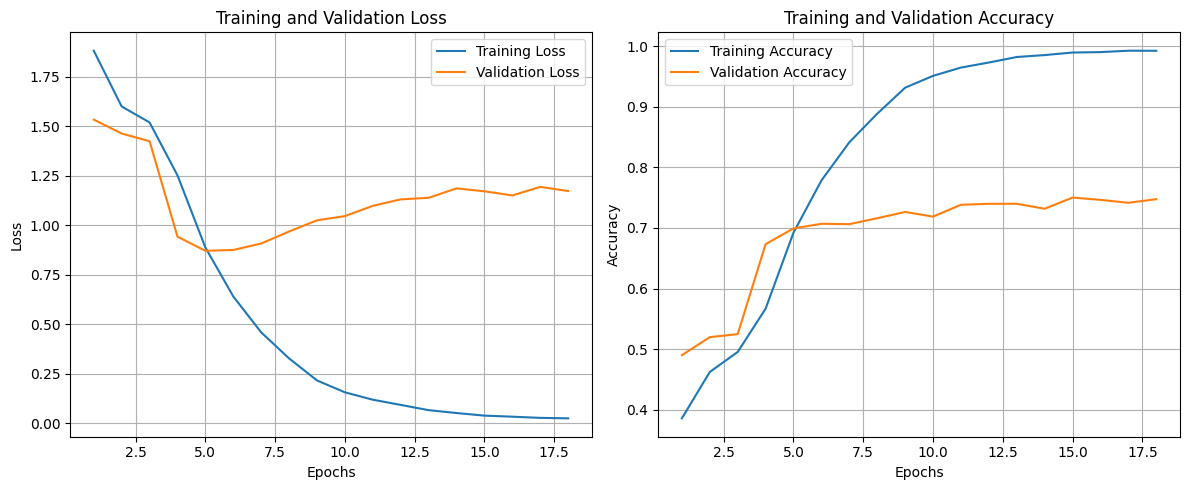

In [ ]:

epochs = range(1, len(all_train_losses) + 1)

plt.figure(figsize=(12, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(epochs, all_train_losses, label='Training Loss')
plt.plot(epochs, all_val_losses, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs, all_train_accs, label='Training Accuracy')
plt.plot(epochs, all_val_accs, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [ ]:
LOCAL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
onnx_path = LOCAL_OUTPUT_DIR / "art_style_identifier.onnx"

In [ ]:
model.eval()

In [ ]:
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")


Trainable parameters: 20,196,703


In [ ]:
dummy_input = torch.randn(1, 3, IMAGE_SIZE, IMAGE_SIZE, device=device)

In [ ]:
try:
    import onnxruntime as ort
except ImportError:
    print("onnxruntime not found. Installing...")
    !pip install onnxruntime
    import onnxruntime as ort
import numpy as np

onnxruntime not found. Installing...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.2/19.2 MB 134.0 MB/s eta 0:00:00


In [ ]:
# Save the class list alongside the model - the ONNX file has no notion of
# label names, only output index order. This file is required at inference.

In [ ]:
class_list_path = LOCAL_OUTPUT_DIR / "classes.json"
with class_list_path.open("w", encoding="utf-8") as f:
    json.dump(CNN_CLASSES, f, ensure_ascii=False, indent=2)
print(f"Class list saved to: {class_list_path}")

Class list saved to: /content/art_style_identifier_checkpoints/classes.json


In [ ]:
session = ort.InferenceSession(str(onnx_path), providers=["CPUExecutionProvider"])


In [ ]:
with torch.no_grad():
    torch_logits = model(dummy_input).cpu().numpy()


In [ ]:
onnx_logits = session.run(["logits"], {"image": dummy_input.cpu().numpy()})[0]

In [ ]:
max_diff = np.abs(torch_logits - onnx_logits).max()
print(f"Max absolute difference between PyTorch and ONNX logits: {max_diff:.6f}")


Max absolute difference between PyTorch and ONNX logits: 0.002490


In [ ]:
if max_diff < 1e-3:
    print("OK: ONNX export matches PyTorch output closely. Safe to deploy.")
else:
    print("WARNING: ONNX output diverges from PyTorch. Do not deploy yet - investigate.")

In [ ]:
# Real-image smoke test through the ONNX path (mirrors production)

In [ ]:
def preprocess_for_onnx(image: Image.Image) -> np.ndarray:
    """Mirrors eval_transform but using only PIL/numpy (no torch), matching
    what the production art_style_identifier.py module will do."""
    image = ImageOps.exif_transpose(image).convert("RGB")
    image = pad_to_square(image)
    image = image.resize((IMAGE_SIZE, IMAGE_SIZE), Image.LANCZOS)

    array = np.array(image).astype(np.float32) / 255.0
    mean = np.array(IMAGENET_MEAN, dtype=np.float32)
    std = np.array(IMAGENET_STD, dtype=np.float32)
    array = (array - mean) / std
    array = array.transpose(2, 0, 1)[np.newaxis, ...]  # HWC -> NCHW

    return array.astype(np.float32)


In [ ]:
#   Copy final artifacts to Drive once, at the end
DRIVE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
shutil.copy2(onnx_path, DRIVE_OUTPUT_DIR / "art_style_identifier.onnx")
shutil.copy2(class_list_path, DRIVE_OUTPUT_DIR / "classes.json")
shutil.copy2(LOCAL_OUTPUT_DIR / "best_model.pt", DRIVE_OUTPUT_DIR / "best_model.pt")


PosixPath('/content/drive/MyDrive/aegis_art_atelier/art_style_identifier/best_model.pt')

In [ ]:
print(f"Final artifacts copied to Drive: {DRIVE_OUTPUT_DIR}")
print(f"  art_style_identifier.onnx")
print(f"  classes.json")
print(f"  best_model.pt (PyTorch checkpoint, kept for reference/retraining)")

Final artifacts copied to Drive: /content/drive/MyDrive/aegis_art_atelier/art_style_identifier
  art_style_identifier.onnx
  classes.json
  best_model.pt (PyTorch checkpoint, kept for reference/retraining)


In [ ]:
!ls -la /content/art_style_identifier_checkpoints/

total 159632
drwxr-xr-x 2 root root     4096 Aug 15 18:47 .
drwxr-xr-x 1 root root     4096 Aug 15 17:14 ..
-rw-r--r-- 1 root root  1278706 Aug 15 18:46 art_style_identifier.onnx
-rw-r--r-- 1 root root 80478208 Aug 15 18:46 art_style_identifier.onnx.data
-rw-r--r-- 1 root root 81688543 Aug 15 18:24 best_model.pt
-rw-r--r-- 1 root root      236 Aug 15 18:47 classes.json


In [ ]:
!cp /content/art_style_identifier_checkpoints/art_style_identifier.onnx /content/drive/MyDrive/aegis_art_atelier/art_style_identifier/